# IEEE 118-Bus Smart Grid with KoopmanGraph

This notebook applies **KoopmanGraph** to the IEEE 118-bus transmission test case — a
standard benchmark in power-systems research (MATPOWER `case118`). We use the real
network topology and simulated bus voltages, then train a topology-aware Koopman
model to forecast future voltage magnitudes.

The evaluation protocol follows common practice in grid forecasting with GNNs:
a **chronological** train / validation / test split, multi-horizon metrics on the
held-out future window, and plots of the **raw** model rollout (no post-hoc
clipping). Similar chronological protocols appear in topology-aware grid learning
work on IEEE / NREL 118-bus systems (for example PowerGNN-style one-step and
multi-step bus-state forecasting).

On this tutorial budget we emphasize **held-out RMSE scale** and whether
**bus Vm ranking** is preserved — not perfect open-loop trajectory shape for the
benchmark’s near-linear decay.

## Domain context (for non-experts)

A power transmission grid is a graph:

- **Buses** are nodes — connection points where loads and generators attach.
- **Branches** (transmission lines, transformers) are edges — they couple buses
  electrically so voltage and power flow propagate across the network.

Each bus carries measurable quantities. The full benchmark tracks four features:

| Feature | Meaning |
|---------|---------|
| **Vm** | Voltage magnitude (per unit) — how "strong" the bus voltage is |
| **Va** | Voltage angle (degrees) — phase relative to a reference |
| **Pd** | Active power demand (per unit on system base) |
| **Qd** | Reactive power demand (per unit on system base) |

This tutorial's primary forecast target is **Vm**, the quantity operators watch
for voltage security. Because buses are coupled through branches, changes at one
bus influence neighbors — exactly the kind of **spatiotemporal graph dynamics**
KoopmanGraph is designed to model.


## The encode → Koopman step → decode workflow

1. **Encode:** A GNN lifts bus features into a latent space while respecting
   the transmission topology.
2. **Koopman step:** A learned matrix $K$ advances latent states linearly:
   $z_{t+1} \approx z_t K^\top$.
3. **Decode:** A GNN maps latent states back to physical bus features.

Training aligns one-step predictions with observed snapshots and adds an
autoregressive rollout term that matches `predict`. Optional forward-consistency
loss encourages linear evolution in latent space.


In [1]:
import warnings

from tqdm.std import TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)

import os

import matplotlib

# Agg is required for headless nbmake/CI runs; interactive kernels use inline.
if os.environ.get("PYTEST_CURRENT_TEST"):
    matplotlib.use("Agg")

import matplotlib.pyplot as plt

try:
    from IPython import get_ipython

    if get_ipython() is not None and not os.environ.get("PYTEST_CURRENT_TEST"):
        get_ipython().run_line_magic("matplotlib", "inline")
except (ImportError, NameError):
    pass

import torch
from torch_geometric.data import Data

from koopman_graph import GNNDecoder, GNNEncoder, GraphKoopmanModel, temporal_split
from koopman_graph.data import GraphSnapshotSequence
from koopman_graph.datasets import IEEE118DynamicBenchmark
from koopman_graph.training import constant_loss_weights

IS_CI = bool(os.environ.get("PYTEST_CURRENT_TEST"))
NUM_TIMESTEPS = 40 if IS_CI else 80
EPOCHS = 40 if IS_CI else 150
PREDICT_STEPS = 3 if IS_CI else 6
EVAL_HORIZONS = (2, 3) if IS_CI else (3, 6)


## Load IEEE 118-bus data

Topology and initial bus states come from the [MATPOWER](https://matpower.org/)
`case118.m` test case. On first use, KoopmanGraph downloads and caches the
parsed network under `data/ieee118/topology.pt`.

You can also refresh the cache manually:

```bash
python scripts/download_ieee118.py
```

`IEEE118DynamicBenchmark.generate` builds a spatiotemporal sequence on the real
118-bus graph: voltages diffuse along transmission lines while loads follow a
slow sinusoidal ramp (a simplified stand-in for changing grid conditions).

We use mild diffusion/decay and a modest load ramp so trajectories evolve
smoothly — easier for the model to learn stable multi-step rollouts on a short
tutorial budget.

> **Note:** For large-scale optimal power flow snapshots, see the
> [PowerGraph dataset](https://arxiv.org/abs/2402.02827).


In [2]:
topology = IEEE118DynamicBenchmark.load_topology()
print(f"Buses: {topology['num_nodes']}")
print(f"Branches (directed edges): {topology['edge_index'].shape[1]}")
print(f"System base MVA: {topology['base_mva']}")

data_sequence = IEEE118DynamicBenchmark.generate(
    num_timesteps=NUM_TIMESTEPS,
    seed=42,
    noise_std=0.0,
    diffusion_rate=0.25,
    decay_rate=0.98,
    load_ramp_amplitude=0.10,
    load_ramp_period=40.0,
)

print(f"Snapshots: {data_sequence.num_timesteps}")
print(f"Feature dim: {data_sequence.in_channels}")
print(f"First snapshot shape: {data_sequence[0].x.shape}")


Buses: 118
Branches (directed edges): 372
System base MVA: 100.0
Snapshots: 80
Feature dim: 4
First snapshot shape: torch.Size([118, 4])


Plot voltage magnitude (Vm) at a few buses over time.


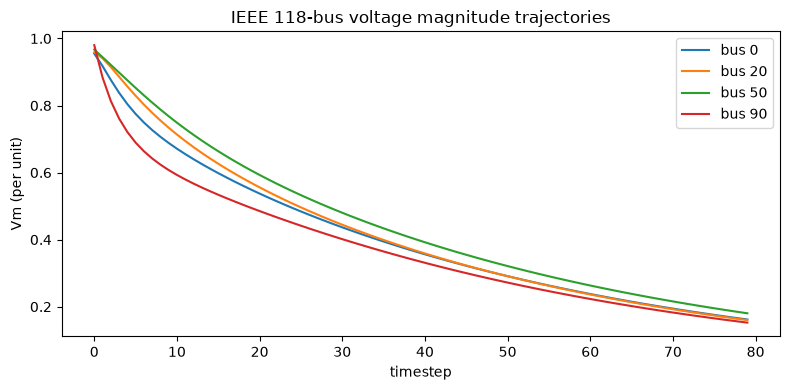

In [3]:
feature_idx = 0  # Vm
bus_ids = [0, 20, 50, 90]
times = torch.arange(data_sequence.num_timesteps)

fig, ax = plt.subplots(figsize=(8, 4))
for bus_id in bus_ids:
    values = torch.stack([snap.x[bus_id, feature_idx] for snap in data_sequence])
    ax.plot(times, values.numpy(), label=f"bus {bus_id}")
ax.set_xlabel("timestep")
ax.set_ylabel("Vm (per unit)")
ax.set_title("IEEE 118-bus voltage magnitude trajectories")
ax.legend()
fig.tight_layout()
plt.show()


## Build the Vm forecasting task

For this short-term voltage tutorial we train on **Vm only**. The four bus
features have very different scales (Vm ≈ 1 p.u., Va in degrees, loads in
per-unit MW/MVAr). A joint unnormalized model would optimize mostly angle
errors. Focusing on Vm matches common short-term voltage forecasting setups
and keeps physical units (p.u.) easy to interpret.

We then apply a **chronological** `temporal_split`: earlier snapshots train the
model, a middle window validates early stopping, and the latest window is held
out for multi-horizon evaluation — the usual protocol when forecasting future
grid states rather than interpolating within the training window.


In [4]:
vm_sequence = GraphSnapshotSequence(
    [
        Data(x=snap.x[:, :1].clone(), edge_index=snap.edge_index)
        for snap in data_sequence
    ]
)

split = temporal_split(
    vm_sequence,
    train_ratio=0.70,
    val_ratio=0.15,
    test_ratio=0.15,
)
print(
    "Train / val / test:",
    f"{split.train.num_timesteps} / {split.val.num_timesteps} / {split.test.num_timesteps}",
)

in_channels = 1
hidden_channels = 64
latent_dim = 64
out_channels = 1

# Seed before constructing modules so their initial weights are reproducible.
torch.manual_seed(0)
encoder = GNNEncoder(in_channels, hidden_channels, latent_dim)
decoder = GNNDecoder(latent_dim, hidden_channels, out_channels)
model = GraphKoopmanModel(
    encoder=encoder,
    decoder=decoder,
    latent_dim=latent_dim,
    time_step=0.1,
)

print(model)


Train / val / test: 56 / 12 / 12
GraphKoopmanModel(
  (encoder): GNNEncoder(
    (activation): ReLU()
    (convs): ModuleList(
      (0): GCNConv(1, 64)
      (1): GCNConv(64, 64)
    )
  )
  (decoder): GNNDecoder(
    (activation): ReLU()
    (convs): ModuleList(
      (0): GCNConv(64, 64)
      (1): GCNConv(64, 1)
    )
  )
  (koopman): KoopmanOperator()
)


## Train

`fit` optimizes one-step reconstruction, forward consistency, and an
autoregressive **rollout** term that matches `predict`. A stronger rollout
weight (`5.0`), gradient clipping, and validation-based early stopping keep
held-out RMSE in a useful range on this short tutorial budget.

The validation sequence uses the same chronological protocol as PowerGNN-style
grid forecasting studies: stop when held-out loss stops improving, then restore
the best checkpoint.


In [5]:
loss_weights = constant_loss_weights(
    reconstruction=1.0,
    forward=1.0,
    rollout=5.0,
)

history = model.fit(
    split.train,
    epochs=EPOCHS,
    lr=1e-3,
    loss_weights=loss_weights,
    rollout_horizon=PREDICT_STEPS,
    max_grad_norm=1.0,
    validation_sequence=split.val,
    early_stopping_patience=30 if not IS_CI else 15,
    restore_best_weights=True,
)

print(f"Epochs run: {len(history.loss)}")
print(f"Initial loss: {history.loss[0]:.6f}")
print(f"Final loss: {history.loss[-1]:.6f}")


Epochs run: 39
Initial loss: 3.139737
Final loss: 0.022892


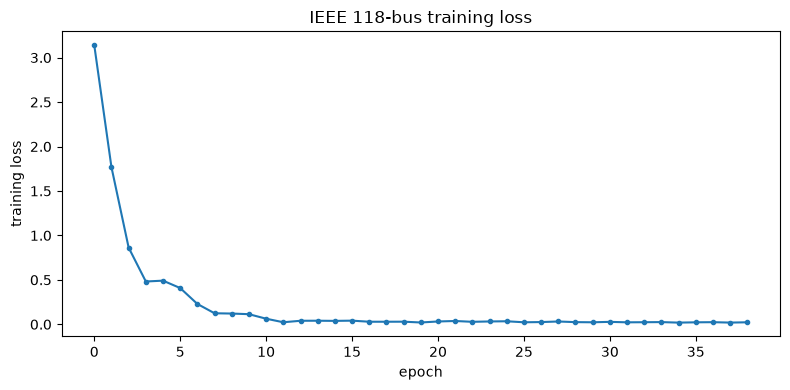

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history.loss, marker="o", markersize=3)
ax.set_xlabel("epoch")
ax.set_ylabel("training loss")
ax.set_title("IEEE 118-bus training loss")
fig.tight_layout()
plt.show()


## Evaluate on the held-out test split

`evaluate` reports MAE and RMSE at short horizons over **all valid origins** in
the chronological test window. Metrics are in physical Vm units (p.u.).

**What we claim from this demo.** On this short tutorial budget the useful
evidence is (1) **held-out RMSE scale** — aggregate and per-bus errors of a few
hundredths of a p.u. — and (2) **topology ranking** — which buses stay higher or
lower in Vm is largely preserved under the raw forecast. We do **not** claim that
the open-loop trajectories match the near-linear decay shape of the benchmark
(persistence or a simple decay-ratio rule can beat GraphKoopman on that axis).

Printed metrics and the figure below both use raw `model.predict` outputs — no
history-based clipping or other post-processing.


In [7]:
result = model.evaluate(split.test, horizons=EVAL_HORIZONS)
for metric in result.horizons:
    print(
        f"horizon {metric.horizon:>2}: "
        f"MAE={metric.mae:.4f} p.u., RMSE={metric.rmse:.4f} p.u."
    )
print(
    f"Aggregate over horizons: "
    f"MAE={result.aggregate_mae:.4f} p.u., "
    f"RMSE={result.aggregate_rmse:.4f} p.u."
)

initial_graph = split.test[0]
future_graphs = model.predict(initial_graph, steps=PREDICT_STEPS)
ground_truth = split.test[1 : PREDICT_STEPS + 1]

rollout_mse = torch.mean(
    torch.stack(
        [
            torch.mean((pred.x - truth.x) ** 2)
            for pred, truth in zip(future_graphs, ground_truth, strict=True)
        ]
    )
)
print(f"Single-origin test rollout MSE: {rollout_mse.item():.6f}")


horizon  3: MAE=0.0254 p.u., RMSE=0.0277 p.u.
horizon  6: MAE=0.0124 p.u., RMSE=0.0147 p.u.
Aggregate over horizons: MAE=0.0189 p.u., RMSE=0.0212 p.u.
Single-origin test rollout MSE: 0.000469


### Held-out RMSE scale and bus ranking

Bus-level RMSE summarizes error magnitude across the 118-bus system. Spearman
rank correlation between per-bus mean truth Vm and mean predicted Vm checks
whether the forecast preserves the **ordering** of strong vs weak buses — the
spatial ranking signal the topology-aware encoder is meant to support.


In [8]:
bus_rmse = []
bus_mean_truth = []
bus_mean_pred = []

for bus_id in range(split.test.num_nodes):
    pred_values = torch.stack([graph.x[bus_id, 0] for graph in future_graphs])
    truth_values = torch.stack([graph.x[bus_id, 0] for graph in ground_truth])
    bus_rmse.append(torch.sqrt(torch.mean((pred_values - truth_values) ** 2)).item())
    bus_mean_truth.append(truth_values.mean().item())
    bus_mean_pred.append(pred_values.mean().item())

bus_rmse_tensor = torch.tensor(bus_rmse)
truth_means = torch.tensor(bus_mean_truth)
pred_means = torch.tensor(bus_mean_pred)
# Spearman via Pearson correlation of ranks (no SciPy dependency).
truth_ranks = truth_means.argsort().argsort().float()
pred_ranks = pred_means.argsort().argsort().float()
rank_corr = torch.corrcoef(torch.stack([truth_ranks, pred_ranks]))[0, 1].item()

print(f"Median bus Vm RMSE: {bus_rmse_tensor.median().item():.4f} p.u.")
print(f"Mean bus Vm RMSE: {bus_rmse_tensor.mean().item():.4f} p.u.")
print(f"90th percentile bus Vm RMSE: {bus_rmse_tensor.quantile(0.9).item():.4f} p.u.")
print(
    f"Buses with RMSE < 0.10 p.u.: "
    f"{int((bus_rmse_tensor < 0.10).sum().item())}/{split.test.num_nodes}"
)
print(f"Spearman rank correlation (mean Vm, truth vs pred): {rank_corr:.3f}")


Median bus Vm RMSE: 0.0215 p.u.
Mean bus Vm RMSE: 0.0200 p.u.
90th percentile bus Vm RMSE: 0.0275 p.u.
Buses with RMSE < 0.10 p.u.: 118/118
Spearman rank correlation (mean Vm, truth vs pred): 0.993


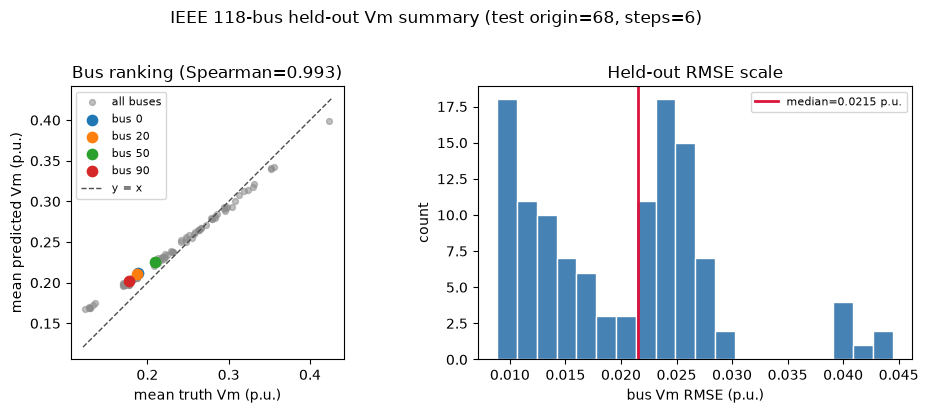

In [9]:
highlight_buses = [0, 20, 50, 90]
median_rmse = bus_rmse_tensor.median().item()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left: topology ranking — mean held-out Vm, truth vs prediction.
ax = axes[0]
ax.scatter(
    truth_means.numpy(),
    pred_means.numpy(),
    s=18,
    alpha=0.55,
    color="0.55",
    label="all buses",
)
for bus_id in highlight_buses:
    ax.scatter(
        [truth_means[bus_id].item()],
        [pred_means[bus_id].item()],
        s=55,
        zorder=3,
        label=f"bus {bus_id}",
    )
lims = [
    min(truth_means.min().item(), pred_means.min().item()),
    max(truth_means.max().item(), pred_means.max().item()),
]
pad = 0.01 * (lims[1] - lims[0] + 1e-8)
ax.plot(
    [lims[0] - pad, lims[1] + pad],
    [lims[0] - pad, lims[1] + pad],
    color="0.3",
    linewidth=1,
    linestyle="--",
    label="y = x",
)
ax.set_xlabel("mean truth Vm (p.u.)")
ax.set_ylabel("mean predicted Vm (p.u.)")
ax.set_title(f"Bus ranking (Spearman={rank_corr:.3f})")
ax.legend(fontsize=8, loc="upper left")
ax.set_aspect("equal", adjustable="box")

# Right: held-out RMSE scale across buses.
ax = axes[1]
ax.hist(bus_rmse_tensor.numpy(), bins=20, color="steelblue", edgecolor="white")
ax.axvline(
    median_rmse,
    color="crimson",
    linewidth=2,
    label=f"median={median_rmse:.4f} p.u.",
)
ax.set_xlabel("bus Vm RMSE (p.u.)")
ax.set_ylabel("count")
ax.set_title("Held-out RMSE scale")
ax.legend(fontsize=8)

fig.suptitle(
    f"IEEE 118-bus held-out Vm summary "
    f"(test origin={split.train.num_timesteps + split.val.num_timesteps}, "
    f"steps={PREDICT_STEPS})",
    y=1.02,
)
fig.tight_layout()
plt.show()


## Controlled dynamics with load-ramp inputs

The benchmark can expose the sinusoidal **load ramp** as an explicit exogenous
control $u_t$. With `control_dim=1`, the Koopman step becomes

$$z_{t+1} \approx z_t K^\top + u_t B,$$

which mirrors Koopman-with-control (DMDc) used in power-systems forecasting.
We also fit a classical **DMDc** baseline on flattened bus states for a quick
topology-agnostic comparison.

> **Expect the baseline to win here.** This benchmark's dynamics are linear in
> the state with a control-affine load ramp — exactly the model class DMDc fits
> by least squares — so the classical baseline recovers the dynamics essentially
> exactly (RMSE ≈ 0) while the briefly-trained nonlinear graph model lags far
> behind. This section demonstrates the control-input API; it is not a setting
> where graph-aware encoding provides an advantage.


In [10]:
from koopman_graph import DMDcBaseline

controlled_sequence = IEEE118DynamicBenchmark.generate(
    num_timesteps=24,
    expose_load_ramp_control=True,
    seed=0,
)
controlled_vm = GraphSnapshotSequence(
    [Data(x=s.x[:, :1], edge_index=s.edge_index) for s in controlled_sequence]
)
controlled_vm = GraphSnapshotSequence(
    controlled_vm.snapshots,
    control_inputs=controlled_sequence.control_inputs,
)

controlled_encoder = GNNEncoder(
    in_channels=1,
    hidden_channels=32,
    latent_dim=16,
)
controlled_decoder = GNNDecoder(
    latent_dim=16,
    hidden_channels=32,
    out_channels=1,
)
controlled_model = GraphKoopmanModel(
    encoder=controlled_encoder,
    decoder=controlled_decoder,
    latent_dim=16,
    time_step=0.25,
    control_dim=1,
)

controlled_history = controlled_model.fit(
    controlled_vm,
    epochs=80 if not IS_CI else 20,
    lr=1e-2,
    loss_weights=constant_loss_weights(reconstruction=1.0, forward=0.1),
)

dmdc = DMDcBaseline(time_step=0.25).fit(controlled_vm)

origin = 0
horizon = 6
future_controls = controlled_vm.rollout_controls(origin, horizon)
controlled_preds = controlled_model.predict(
    controlled_vm[origin],
    steps=horizon,
    controls=future_controls,
)
dmdc_preds = dmdc.predict(
    controlled_vm[origin],
    steps=horizon,
    controls=future_controls,
)

controlled_rmse = torch.sqrt(
    torch.mean(
        (controlled_preds[-1].x - controlled_vm[origin + horizon].x) ** 2
    )
).item()
dmdc_rmse = torch.sqrt(
    torch.mean((dmdc_preds[-1].x - controlled_vm[origin + horizon].x) ** 2)
).item()

print(f"Controlled GraphKoopman RMSE @ {horizon} steps: {controlled_rmse:.4f}")
print(f"DMDc baseline RMSE @ {horizon} steps: {dmdc_rmse:.4f}")
print(f"Training loss (final): {controlled_history.loss[-1]:.4f}")


Controlled GraphKoopman RMSE @ 6 steps: 0.5380
DMDc baseline RMSE @ 6 steps: 0.0000
Training loss (final): 0.0024


## Takeaways

- **IEEE 118 topology** from MATPOWER anchors a realistic transmission graph;
  the dynamic benchmark adds Laplacian voltage diffusion plus a load ramp.
- **Chronological splitting** evaluates forecasts on a future window, matching
  how short-term grid forecasting papers typically report accuracy.
- **Claim supported here:** held-out RMSE is on the order of a few hundredths of
  a p.u., and per-bus mean Vm **ranking** (Spearman) is largely preserved under
  raw `predict`. Trajectory-shape fidelity to the near-linear decay is **not**
  the takeaway — simple decay rules can beat GraphKoopman on that axis.
- **DMDc** still wins on the control-affine load-ramp demo — an honest reminder
  that classical linear models can dominate when the data-generating process
  matches their assumptions.

## Next steps

- See [`01_synthetic_graph.ipynb`](01_synthetic_graph.ipynb) for a smaller
  synthetic graph walkthrough.
- **All four bus features:** z-score normalize each channel on the **training**
  split only, then evaluate in denormalized units — or train separate models per
  quantity (Vm, Va, loads).
- **Longer horizons / structural `K`:** see
  [`11_long_horizon_stability.ipynb`](11_long_horizon_stability.ipynb).
- Explore the [API reference](https://koopmangraph.readthedocs.io/en/latest/api.html)
  for loss weights, early stopping, and GAT encoders.
- See [`03_traffic_network.ipynb`](03_traffic_network.ipynb) for METR-LA traffic
  speed forecasting on a road sensor network.
